In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Student Social Media And Mental Health Impact.csv')
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [5]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [6]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [8]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df=df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

# DISTRIBUTION OF TARGET COLUMN


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

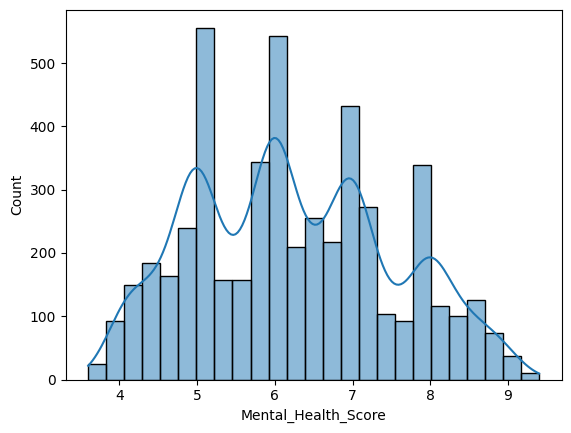

In [12]:
sns.histplot(df['Mental_Health_Score'],kde=True)

# CORRELATION

<Axes: >

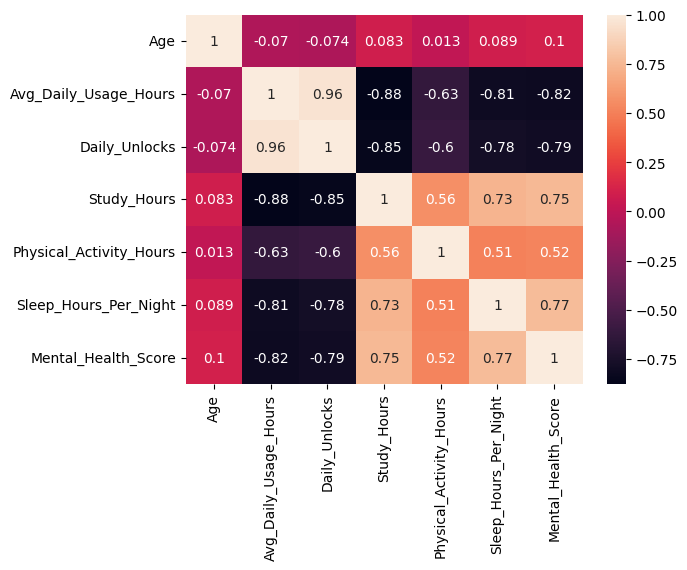

In [13]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

CHECKING OUTLIERS

In [14]:
## Finding num_features
num_features=df.select_dtypes(include='number')

Q1=num_features.quantile(0.25)
Q3=num_features.quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outlier= (num_features<lower_bound) | (num_features>upper_bound)
print(outlier.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    12
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


SKWENESS

In [15]:
num_cols=df.select_dtypes(include='number')
num_cols.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [16]:
top_countries=df['Country'].value_counts().index[:10].tolist()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [17]:
 ## First 10 repeating countries grouped together in --  'Grouped_Countries'
 ## Remaining will be grouped together in -- 'others'

top_countries=df['Country'].value_counts().index[:10].tolist()

def Grouped_Countries(Country):
  if Country in top_countries:
    return Country
  else:
    return 'Others'

df['Grouped_Country']=df['Country'].apply(Grouped_Countries)
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_Country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [18]:
top_countries=df['Country'].value_counts().index[:10].tolist()

In [19]:
df['Grouped_Country'].value_counts()

,count
Grouped_Country,
Other,1879
Others,1352
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94


Train test split

In [20]:
from sklearn.model_selection import train_test_split
skew_col=['Study_Hours']

numerical_cols=["Age","Avg_Daily_Usage_Hours","Daily_Unlocks",
                  "Physical_Activity_Hours","Sleep_Hours_Per_Night"]
ordinal_col=['Stress_Level']

oh_cols=["Gender","Grouped_Country","Most_Used_Platform","Academic_Level","Purpose_Of_Use"]

features_cols=skew_col+numerical_cols+oh_cols+ordinal_col
X=df.drop('Mental_Health_Score',axis=1)
y=df['Mental_Health_Score']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

ENCODING:
PIPELINE

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer

skew_pipline=Pipeline(steps=[
    ('log_transformer',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])

numerical_pipeline=Pipeline(steps=[
    ('scaler',StandardScaler())
])

ordinal_pipeline=Pipeline(steps=[

  ('OrdinalEncoder',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])

oh_pipeline=Pipeline(steps=[
    ('one_hot_encoder',OneHotEncoder(handle_unknown='ignore'))
])

In [22]:
preprocessor=ColumnTransformer(transformers=[
    ('skew_pipline',skew_pipline,skew_col),
    ('numerical_pipeline',numerical_pipeline,numerical_cols),
    ('ordinal_pipeline',ordinal_pipeline,ordinal_col),
    ('oh_pipeline',oh_pipeline,oh_cols)
])

In [23]:
preprocessor

ColumnTransformer(transformers=[('skew_pipline',
                                 Pipeline(steps=[('log_transformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Study_Hours']),
                                ('numerical_pipeline',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('ordinal_pipeline',
                                 Pipeline(steps=[('OrdinalEncoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('oh_pipeline',
                                 Pipeline(steps=[('one_hot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Grouped_Country',
                                  'Most_Used_Platform', 'Academic_Level',
                                  'Purpose_Of_Use'])])

MODEL TRAINING

BASE MODEL

In [24]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression

lr_pipeline=Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('linear_regression',LinearRegression())
])
lr_pipeline.fit(X_train,y_train)


## Prediction on Test Data
y_pred=lr_pipeline.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print('Test Results')
print('Test_MAE:',mae)
print('Test_MSE:',mse)
print('Test_R2:',r2)


## Prediction on Train Data
y_train_pred=lr_pipeline.predict(X_train)

print('Train Results')
Train_mae=mean_absolute_error(y_train,y_train_pred)
Train_mse=mean_squared_error(y_train,y_train_pred)
Train_r2=r2_score(y_train,y_train_pred)
print('Train_MAE:',Train_mae)
print('Train_MSE:',Train_mse)
print('Train_R2:',Train_r2)

Test Results
Test_MAE: 0.5338363831333407
Test_MSE: 0.44806572531776084
Test_R2: 0.7448268003326601
Train Results
Train_MAE: 0.5179094488005774
Train_MSE: 0.42500529448624896
Train_R2: 0.7332357307717248


BETTER MODEL

RANDOM FOREST REGRESSOR

In [25]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline=Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('random_forest',RandomForestRegressor())
])
rf_pipeline.fit(X_train,y_train)

y_pred=rf_pipeline.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print('Test Results')
print('Test_MAE:',mae)
print('Test_MSE:',mse)
print('Test_R2:',r2)

y_train_pred=rf_pipeline.predict(X_train)

print('Train Results')
Train_mae=mean_absolute_error(y_train,y_train_pred)
Train_mse=mean_squared_error(y_train,y_train_pred)
Train_r2=r2_score(y_train,y_train_pred)
print('Train_MAE:',Train_mae)
print('Train_MSE:',Train_mse)
print('Train_R2:',Train_r2)

Test Results
Test_MAE: 0.31620550666666675
Test_MSE: 0.18151758238600005
Test_R2: 0.8966258303723916
Train Results
Train_MAE: 0.11756168623265752
Train_MSE: 0.026595802528014977
Train_R2: 0.9833065377820723


HYPER PARAMETER TUNING

In [26]:
from sklearn.model_selection import  RandomizedSearchCV
param_grid={
    'model__n_estimators' : [100,200,300],
    'model__max_depth' :[10,20,30],
    'model__min_samples_split' : [2,5,10],
    'model__min_samples_leaf' : [1,2,4]
}
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),  # handles encoding & scaling
    ('model', RandomForestRegressor(random_state=42))
])

Random=RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    cv=3,
    n_jobs=-1
    )
Random.fit(X_train,y_train)
print(Random.best_params_)

{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 20}


In [27]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline=Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('random_forest',RandomForestRegressor(
        n_estimators = 300,
        min_samples_split=5,
        min_samples_leaf= 2,
        max_depth= 30))
])
rf_pipeline.fit(X_train,y_train)

y_pred=rf_pipeline.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print('Test Results')
print('Test_MAE:',mae)
print('Test_MSE:',mse)
print('Test_R2:',r2)

y_train_pred=rf_pipeline.predict(X_train)

print('Train Results')
Train_mae=mean_absolute_error(y_train,y_train_pred)
Train_mse=mean_squared_error(y_train,y_train_pred)
Train_r2=r2_score(y_train,y_train_pred)
print('Train_MAE:',Train_mae)
print('Train_MSE:',Train_mse)
print('Train_R2:',Train_r2)

Test Results
Test_MAE: 0.33000687378873844
Test_MSE: 0.19662670411395922
Test_R2: 0.8880211933344828
Train Results
Train_MAE: 0.16299879353365224
Train_MSE: 0.05146836625682518
Train_R2: 0.9676947057107322


**SAVING MODEL AS PICKLE**

In [28]:
import joblib

# Save
joblib.dump(rf_pipeline, 'mental_health_project.pkl')

['mental_health_project.pkl']